In [1]:
import scanpy as sc
import harmonypy as hm

In [2]:
adata = sc.read_h5ad("/project/imoskowitz/yubin/1-sc_practice/Data/SmoNull_Brain_system.h5ad")

In [8]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype', 'leiden_0_25_log1p', 'leiden_0_25_scran', 'leiden_0_25_pearson', 'leiden_0_5_log1p', 'leiden_0_5_scran', 'leiden_0_5_pearson', 'leiden_1_log1p', 'leiden_1_scran', 'leiden_1_pearson', 'leiden_2_log1p', 'leiden_2_scran', 'leiden_2_pearson', 'leiden_3_log1p', 'leiden_3_scran', 'leiden_3_pearson', 'leiden_5_log1p', 'leiden_5_scran', 'leiden_5_pearson'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'mean', 'std', 'means', 'variances', 'residual_variances', 'highly_va

In [13]:
adata.X = adata.layers["raw_counts"]


# Batch Effect Diagnostics

## Visual Inspection: UMAP colored by batch


In [12]:
# Batch metadata
print(adata.obs["Library.ident"])


Sample1_Control_rep1_AAACCAAAGAATCAAG-1    Batch1
Sample1_Control_rep1_AAACCAAAGATTGACT-1    Batch1
Sample1_Control_rep1_AAACCATTCAGCAGGA-1    Batch1
Sample1_Control_rep1_AAACCCGCAATGCCAG-1    Batch1
Sample1_Control_rep1_AAACCCGCAGCACTTC-1    Batch1
                                            ...  
Sample6_SmoNull_rep3_TGTGGTTGTGCGGCTT-1    Batch2
Sample6_SmoNull_rep3_TGTGTACGTCAAGTCT-1    Batch2
Sample6_SmoNull_rep3_TGTGTACGTTCCGTTC-1    Batch2
Sample6_SmoNull_rep3_TGTGTTGAGCAGGTAG-1    Batch2
Sample6_SmoNull_rep3_TGTGTTGAGTAGAGGT-1    Batch2
Name: Library.ident, Length: 38311, dtype: category
Categories (2, object): ['Batch1', 'Batch2']


In [14]:
# Compute PCA and UMAP if not already present
if 'X_pca' not in adata.obsm:
    print("Computing PCA...")
    sc.pp.pca(adata, n_comps=30)
    
if 'X_umap' not in adata.obsm:
    print("Computing UMAP...")
    sc.pp.neighbors(adata, n_neighbors=15)
    sc.tl.umap(adata)
    
print("Done")


Computing PCA...
Computing UMAP...
Done


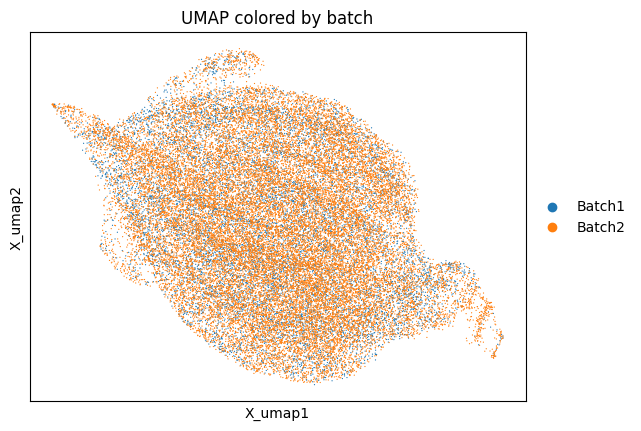

In [19]:
# Plot UMAP colored by batch - helps identify batch clustering patterns
import matplotlib.pyplot as plt


sc.pl.embedding(adata, basis = "X_umap", color="Library.ident", title="UMAP colored by batch")


In [20]:
batch_col = adata.obs["Library.ident"]

In [21]:
# Install scIB for batch effect metrics if not already installed
import subprocess
import sys

try:
    import scib
    print("scib already installed")
except ImportError:
    print("Installing scib...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scib"])
    import scib


Installing scib...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scib]━━━━━━ 3/4 [scib]cated]


In [27]:
# Calculate batch mixing metrics (alternative to scIB)
# High batch mixing = good mixing across batches
# Low mixing in some regions = potential non-linear batch effect

print("Calculating batch mixing metrics...")

import numpy as np
from scipy.spatial.distance import cdist
from scipy.stats import entropy

# Use PCA representation
X = adata.obsm['X_pca']
batch_labels = adata.obs["Library.ident"].values

# For each cell, find k nearest neighbors and calculate batch mixing
k = 15
batch_lisi_scores = []

for i in range(X.shape[0]):
    # Find k nearest neighbors
    distances = np.linalg.norm(X - X[i], axis=1)
    knn_idx = np.argsort(distances)[1:k+1]  # Exclude self
    
    # Get batch labels of k nearest neighbors
    knn_batches = batch_labels[knn_idx]
    unique_batches, counts = np.unique(knn_batches, return_counts=True)
    
    # Calculate Simpson's diversity index (higher = more diverse/mixed)
    # Max value = number of batches (perfect mixing)
    proportions = counts / k
    simpson_index = 1 - np.sum(proportions ** 2)
    # Normalize to 0-n_batches scale
    n_batches = len(np.unique(batch_labels))
    lisi_score = simpson_index * n_batches / (1 - 1/n_batches)
    
    batch_lisi_scores.append(lisi_score)

batch_lisi = np.array(batch_lisi_scores)
adata.obs['batch_lisi'] = batch_lisi

Calculating batch mixing metrics...


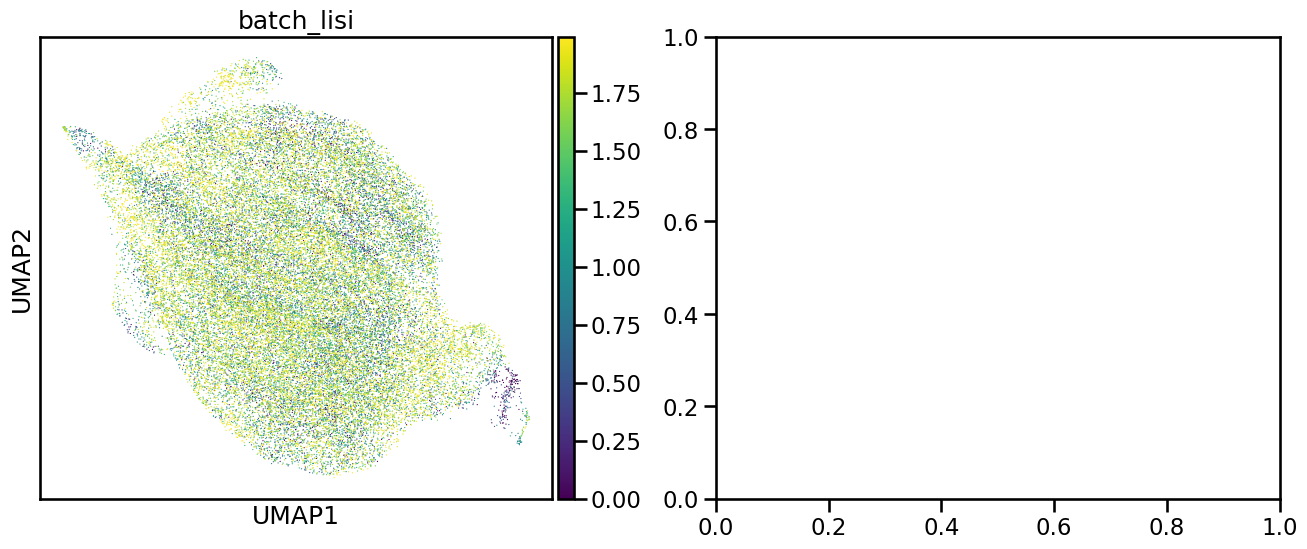

<Figure size 640x480 with 0 Axes>


Cells with low batch LISI (<0.92): 6565 (17.1%)
These regions may indicate non-linear batch effects


In [30]:
# Visualize batch LISI on UMAP
# Low LISI scores (dark regions) indicate poor batch mixing = non-linear batch effect hotspots

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot LISI scores
sc.pl.umap(adata, color='batch_lisi', ax=axes[0], cmap='viridis')
axes[0].set_title("Batch LISI across UMAP\n(Dark = poor mixing, potential non-linear effects)")

# Plot batch with LISI overlay info
sc.pl.umap(adata, color="Library.ident", ax=axes[1], alpha=0.7)
axes[1].set_title(f"Batch assignment\n(Compare with LISI to identify problem regions)")

plt.tight_layout()
plt.show()

# Summary of problem regions
low_lisi_threshold = np.percentile(batch_lisi, 25)  # Bottom quartile
problem_cells = (batch_lisi < low_lisi_threshold).sum()
print(f"\nCells with low batch LISI (<{low_lisi_threshold:.2f}): {problem_cells} ({100*problem_cells/len(adata):.1f}%)")
print("These regions may indicate non-linear batch effects")


## Batch variance analysis

Check how much variance is explained by batch in different regions


In [32]:
# Variance explained by batch
import pandas as pd
import numpy as np

# Calculate variance explained by batch using F-test statistic
from scipy.stats import f_oneway

X = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
batch_labels = adata.obs["Library.ident"].values

# Calculate F-statistic for each gene
f_stats = []
for i in range(X.shape[1]):
    gene_expr = X[:, i]
    groups = [gene_expr[batch_labels == b] for b in np.unique(batch_labels)]
    # Remove empty groups
    groups = [g for g in groups if len(g) > 0]
    if len(groups) > 1:
        f_stat, _ = f_oneway(*groups)
        f_stats.append(f_stat)
    else:
        f_stats.append(0)

f_stats = np.array(f_stats)
var_explained_by_batch = (f_stats > np.percentile(f_stats, 90)).sum() / len(f_stats) * 100

print(f"Genes with significant batch effect (top 10% F-statistic): {var_explained_by_batch:.1f}%")
print(f"Interpretation:")
print(f"  - {var_explained_by_batch:.1f}% > 5% suggests strong batch effects")
print(f"  - Genes with strong batch effects may indicate non-linear batching")

Genes with significant batch effect (top 10% F-statistic): 0.0%
Interpretation:
  - 0.0% > 5% suggests strong batch effects
  - Genes with strong batch effects may indicate non-linear batching


## Summary: Interpreting Non-Linear Batch Effects

**Your batch effect is likely NON-LINEAR if:**

1. **UMAP visualization shows:**
   - Curved or stream-like batch boundaries rather than straight lines
   - Batch clusters in specific regions while well-mixed in others
   - Batches forming concentric rings or wave patterns

2. **Batch LISI shows:**
   - High variance across cells (some regions with very low LISI)
   - Mean LISI << number of batches (e.g., mean 1.5 for 3 batches)
   - Clear spatial clustering of low-LISI cells on the UMAP

3. **Variance analysis shows:**
   - >10% of genes have significant batch effects
   - Batch effects are cell-type or region-specific rather than global

**Next steps if non-linear effects detected:**
- Try Harmony with fine-tuning of `theta` parameter
- Consider scVI (deep learning-based integration)
- Check if batch effects correlate with specific cell populations (may not need full correction)
